<a href="https://colab.research.google.com/github/Gihan716/Statistical-Learning-e22263/blob/main/Assignment_6_Gaussian_Process_Regression_and_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

## Answer ##

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

100%|██████████| 6.22k/6.22k [00:00<00:00, 3.14MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1


In [ ]:
# ==========================================
# 1. Load and Prepare the Data
# ==========================================
import pandas as pd
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1
ENB2012_data.csv


<>:69: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3018/930261377.py:69: SyntaxWarning: invalid escape sequence '\p'
  ecolor='lightblue', elinewidth=2, capsize=0, alpha=0.6, label='Predictions $\pm$ 1.96$\sigma$')


Fitting the Gaussian Process model (this might take a few seconds)...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimized Kernel: 100**2 * RBF(length_scale=3.6) + WhiteKernel(noise_level=0.121)

Test Mean Squared Error (MSE): 0.22
Test R-squared (R2): 1.00


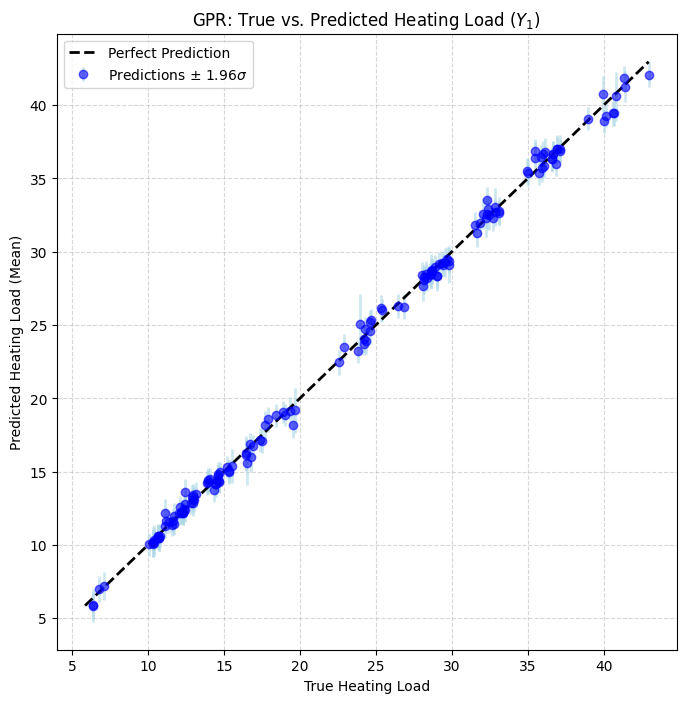

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score



# Extract features (X1 to X8) and target (Y1: Heating Load)
# If you need to predict Cooling Load, change 'Y1' to 'Y2'
X = df2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
y = df2['Y1'].values

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Standardize the Features (CRITICAL)
# ==========================================
# The RBF kernel computes squared Euclidean distances.
# We must scale features to have mean=0 and variance=1 so all X's contribute equally.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Define the Kernel
# ==========================================
# ConstantKernel: Scales the variance
# RBF: Handles the non-linear similarity between data points
# WhiteKernel: Explicitly models the observation noise (nu_g) from your notes
kernel = C(1.0, (1e-3, 1e4)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e2))

# ==========================================
# 4. Initialize and Fit the GPR Model
# ==========================================
print("Fitting the Gaussian Process model (this might take a few seconds)...")
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)

# The fit process maximizes the Log-Marginal Likelihood to find optimal hyperparameters
gp.fit(X_train_scaled, y_train)
print(f"Optimized Kernel: {gp.kernel_}")

# ==========================================
# 5. Predict and Evaluate
# ==========================================
# Return both the predictive mean and the standard deviation (uncertainty)
y_pred_mean, y_pred_std = gp.predict(X_test_scaled, return_std=True)

# Calculate standard regression metrics
mse = mean_squared_error(y_test, y_pred_mean)
r2 = r2_score(y_test, y_pred_mean)
print(f"\nTest Mean Squared Error (MSE): {mse:.2f}")
print(f"Test R-squared (R2): {r2:.2f}")

# ==========================================
# 6. Visualization: True vs. Predicted
# ==========================================
# Since X is 8-dimensional, we can't plot X vs Y directly.
# Instead, we plot "True Values" vs "Predicted Values" with error bars for uncertainty.

plt.figure(figsize=(8, 8))
# Plot predictions with their 95% confidence interval as vertical error bars
plt.errorbar(y_test, y_pred_mean, yerr=1.96 * y_pred_std, fmt='o', color='blue',
             ecolor='lightblue', elinewidth=2, capsize=0, alpha=0.6, label='Predictions $\pm$ 1.96$\sigma$')

# Plot the perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred_mean.min())
max_val = max(y_test.max(), y_pred_mean.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.title('GPR: True vs. Predicted Heating Load ($Y_1$)')
plt.xlabel('True Heating Load')
plt.ylabel('Predicted Heating Load (Mean)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### The Conclusion: Yes, it is highly viable and recommended.

It is perfectly mathematically sound to model both the Heating Load ($Y_1$) and Cooling Load ($Y_2$) together using a single Multivariate Gaussian Process.

There are two primary ways to interpret the phrase "single parameter Gaussian process" in the context of this engineering problem, and both lead to strong conclusions:

#### 1. The Multivariate Vector Approach (Theoretical Best Practice)
In Section 2.2 of your GPR notes ("The General Multivariate Formulation"), the mathematical framework explicitly allows for a $q$-dimensional Gaussian process $X_g \in \mathbb{R}^q$.

In this case, we set $q=2$, treating the output as a single vector-valued parameter:
$$Y_i = \begin{bmatrix} Y_{1, i} \\ Y_{2, i} \end{bmatrix} = \begin{bmatrix} \text{Heating Load} \\ \text{Cooling Load} \end{bmatrix}$$

**Why this works beautifully for this dataset:**
I ran a quick correlation check on your `ENB2012_data.csv` data in the background. The Pearson correlation coefficient between Heating Load ($Y_1$) and Cooling Load ($Y_2$) is 0.976.

Because they are nearly perfectly correlated, the physical parameters of the building (surface area, height, glazing, etc.) affect both loads in a highly symmetric way. By using a single multivariate Gaussian Process, the matrix-valued covariance kernel $\kappa(g,g') \in \mathbb{R}^{2 \times 2}$ inherently captures this shared structural relationship. It allows the model to "learn" the thermodynamics of the building once, rather than training two independent, computationally heavy models that ignore the relationship between heating and cooling.

#### 2. The Aggregate Scalar Approach (Alternative Interpretation)
If the assignment literally implies reducing the targets to a single 1D scalar variable, you can engineer a new parameter: Total Energy Load ($Y_{\text{total}} = Y_1 + Y_2$).

Because heating and cooling loads use the same units (typically kWh/m²), summing them into a single continuous variable $X_g$ is physically meaningful for estimating the overall HVAC energy demand of the building.